# Task 2: Stock Price Prediction

## Objective
The objective of this project is to predict the next day's stock closing price using historical stock market data and machine learning techniques.

The project uses:
- Yahoo Finance API
- Linear Regression
- Data visualization techniques

In [16]:
# Import required libraries

import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

## Fetching Historical Stock Data

Historical stock data is fetched using the yfinance library.

In [3]:
# Download Apple stock data

stock_data = yf.download("AAPL", start="2020-01-01", end="2024-01-01")

stock_data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.333885,72.394093,71.091191,71.344062,135480400
2020-01-03,71.630638,72.389257,71.406666,71.563205,146322800
2020-01-06,72.201408,72.239942,70.503546,70.754014,118387200
2020-01-07,71.861855,72.466338,71.642697,72.211056,108872000
2020-01-08,73.017845,73.318885,71.565629,71.565629,132079200


In [4]:
# Display dataset shape

stock_data.shape

(1006, 5)

In [5]:
# Display dataset information

stock_data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1006 entries, 2020-01-02 to 2023-12-29
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1006 non-null   float64
 1   (High, AAPL)    1006 non-null   float64
 2   (Low, AAPL)     1006 non-null   float64
 3   (Open, AAPL)    1006 non-null   float64
 4   (Volume, AAPL)  1006 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 47.2 KB


In [6]:
# Statistical summary

stock_data.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,1006.000000,1006.000000,1006.000000,1006.000000,1.006000e+03
mean,137.831006,139.310700,136.203195,137.701085,9.895373e+07
std,33.327124,33.447106,33.188109,33.320865,5.439610e+07
min,54.163696,55.160694,51.324793,55.059305,2.404830e+07
25%,120.286219,121.526052,118.754707,120.391648,6.407675e+07
50%,142.684914,144.257336,141.024906,142.534809,8.467540e+07
75%,163.044834,165.318747,161.792363,163.312360,1.155069e+08
max,195.892639,197.385733,194.795030,195.803650,4.265100e+08


## Feature Selection

Selecting input features and target variable for model training.

In [7]:
# Define input features

X = stock_data[['Open', 'High', 'Low', 'Volume']]

# Define target variable

y = stock_data['Close']

In [8]:
# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Model Training

Training a Linear Regression model using historical stock data.

In [9]:
# Create Linear Regression model

model = LinearRegression()

# Train model

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [10]:
# Make predictions

predictions = model.predict(X_test)

## Actual vs Predicted Prices

Visual comparison between actual and predicted closing prices.

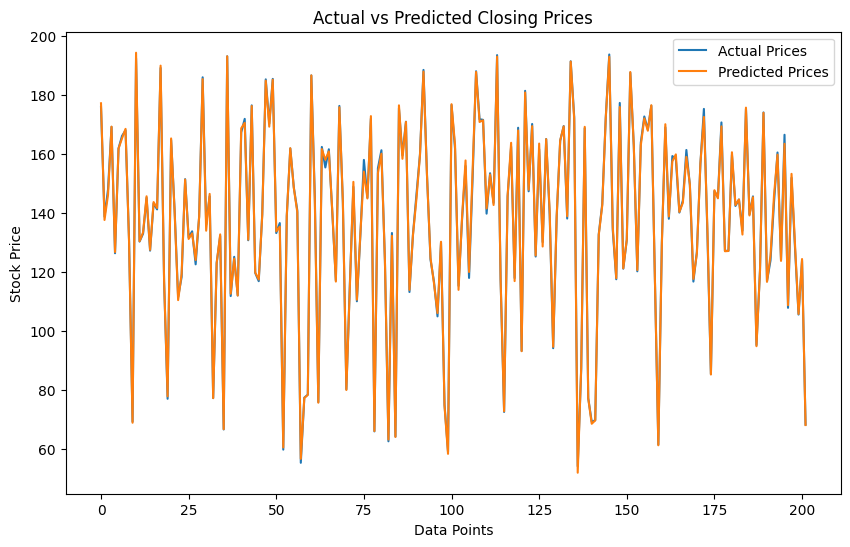

In [11]:
# Plot actual vs predicted prices

plt.figure(figsize=(10,6))

plt.plot(y_test.values, label='Actual Prices')
plt.plot(predictions, label='Predicted Prices')

plt.title("Actual vs Predicted Closing Prices")
plt.xlabel("Data Points")
plt.ylabel("Stock Price")

plt.legend()

plt.show()

In [12]:
# Calculate Mean Absolute Error

mae = mean_absolute_error(y_test, predictions)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 0.7003789244517581


In [17]:
# Calculate Mean Squared Error
mse = mean_squared_error(y_test, predictions)

# Convert to Root Mean Squared Error
rmse = np.sqrt(mse)

print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 0.9485700726205204


## 📌 Final Insights

- Historical stock market data was successfully retrieved using the Yahoo Finance API.
- A supervised machine learning pipeline was built to predict next-day closing prices.
- Features such as Open, High, Low, and Volume were used as input variables.
- A Linear Regression model was trained and evaluated on unseen test data.
- Model performance was measured using MAE and RMSE, showing low average prediction error.
- The predicted values followed the general trend of actual stock prices, but did not perfectly capture market volatility, which is expected for a simple linear model.
- This project demonstrates a complete end-to-end workflow of data collection, preprocessing, model training, evaluation, and visualization in a financial forecasting use case.